# Block 3 — SOLUTION: Engineered Features & Denoising With ML Models
### Advanced Machine Learning — M&T Bank

Starts from `bank_marketing_clean.csv` (Block 2's output). Produces `bank_marketing_features.csv`, which
carries forward into Linear Models (Block 4) and every block after it.

**Part 1 — Engineer:** bin `age`, ordinal-encode `education`, one-hot encode the remaining nominal columns,
cyclically encode `month`, derive `campaign_intensity`.

**Part 2 — Denoise:** check the macro-economic correlations, fit PCA, reconstruct the five macro columns from
the top 3 components, compare before/after.


## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"

# Paste the raw GitHub URL for bank_marketing_clean.csv below, then remove the leading '#':
# df = pd.read_csv("PASTE_RAW_GITHUB_URL_HERE", sep=";")
print(df.shape)
df.head()


# Part 1 — Engineered Features

### Task 1.1 — Bin `age` into life-stage bands

`age` ranges 17–98 (median 38). A raw linear term forces the model to assume risk moves in a straight line with
age, which rarely holds. Binning lets a model treat each life stage independently.


In [2]:
age_bins = [17, 25, 35, 45, 55, 65, 98]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]

df["age_band"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, include_lowest=True)

df[["age", "age_band"]].sample(8, random_state=1)


,age,age_band
35577,32,26-35
13950,33,26-35
29451,25,18-25
32295,34,26-35
27477,53,46-55
31507,46,46-55
32167,33,26-35
24580,46,46-55


### Task 1.2 — Ordinal-encode `education`

Education has a genuine order — `illiterate` is not "a different category" from `university.degree`, it's *less*
of the same thing. Ordinal encoding preserves that; one-hot encoding would throw it away.


In [3]:
education_order = [
    "illiterate", "basic.4y", "basic.6y", "basic.9y",
    "high.school", "professional.course", "university.degree",
]
education_rank_map = {level: rank for rank, level in enumerate(education_order)}

df["education_rank"] = df["education"].map(education_rank_map)

df[["education", "education_rank"]].drop_duplicates().sort_values("education_rank")


,education,education_rank
5393,illiterate,0
0,basic.4y,1
3,basic.6y,2
5,basic.9y,3
1,high.school,4
6,professional.course,5
7,university.degree,6


### Task 1.3 — One-hot encode the remaining nominal columns

`job`, `marital`, `default`, `housing`, `loan`, `contact`, `day_of_week`, `poutcome`, and our new `age_band` have
no real order — one-hot encoding avoids implying a false ranking between, say, `"admin."` and `"technician"`.


In [4]:
nominal_cols = [
    "job", "marital", "default", "housing", "loan",
    "contact", "day_of_week", "poutcome", "age_band",
]

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print("columns before:", df.shape[1], "-> after one-hot:", df_encoded.shape[1])
df_encoded.filter(like="job_").head()


columns before: 24 -> after one-hot: 43


,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False


### Task 1.4 — Cyclically encode `month`

`month` wraps around — December (12) and January (1) are one month apart, not eleven. A sine/cosine pair encodes
that adjacency; a raw integer or a one-hot column can't.


In [5]:
month_number = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12,
}
month_num = df_encoded["month"].map(month_number)

df_encoded["month_sin"] = np.sin(2 * np.pi * month_num / 12)
df_encoded["month_cos"] = np.cos(2 * np.pi * month_num / 12)

df_encoded = df_encoded.drop(columns=["month"])
df_encoded[["month_sin", "month_cos"]].drop_duplicates().round(2)


,month_sin,month_cos
0,0.50,-0.87
7763,0.00,-1.00
12137,-0.50,-0.87
18822,-0.87,-0.50
23997,-0.87,0.50
24064,-0.50,0.87
27680,-0.00,1.00
27690,1.00,0.00
27972,0.87,-0.50
37887,-1.00,-0.00


### Task 1.5 — Derive `campaign_intensity`

One number that captures "contacted a lot this campaign, with little prior success": a high value flags clients
being pushed hard despite a weak track record.


In [6]:
df_encoded["campaign_intensity"] = df_encoded["campaign"] / (df_encoded["previous"] + 1)

df_encoded[["campaign", "previous", "campaign_intensity"]].describe()


,campaign,previous,campaign_intensity
count,41188.000000,41188.000000,41188.000000
mean,2.567593,0.172963,2.424386
std,2.770014,0.494901,2.785705
min,1.000000,0.000000,0.125000
25%,1.000000,0.000000,1.000000
50%,2.000000,0.000000,2.000000
75%,3.000000,0.000000,3.000000
max,56.000000,7.000000,56.000000


**Note on `duration`:** we're leaving it as-is for now. It's the single strongest predictor in this dataset — and
also the dataset's own documented leakage trap, since call length is only known *after* the call happens. Worth
flagging here; we'll come back to it directly when we talk about realistic evaluation in Block 4.


### Task 1.6 — Encode the target

One last housekeeping step: turn `y` into a 0/1 column so every model we fit from Block 4 onward can use it directly.


In [7]:
df_encoded["y"] = (df_encoded["y"] == "yes").astype(int)
df_encoded["y"].value_counts()


y
0    36548
1     4640
Name: count, dtype: int64

# Part 2 — Denoising With ML Models (PCA)

### Task 2.1 — Check the macro-economic correlations

Five columns describe the same broad economic backdrop for every call: `emp.var.rate`, `cons.price.idx`,
`cons.conf.idx`, `euribor3m`, `nr.employed`. Let's see how independent they really are.


In [8]:
macro_cols = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

corr = df_encoded[macro_cols].corr()
corr.round(2)


,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
emp.var.rate,1.00,0.78,0.20,0.97,0.91
cons.price.idx,0.78,1.00,0.06,0.69,0.52
cons.conf.idx,0.20,0.06,1.00,0.28,0.10
euribor3m,0.97,0.69,0.28,1.00,0.95
nr.employed,0.91,0.52,0.10,0.95,1.00


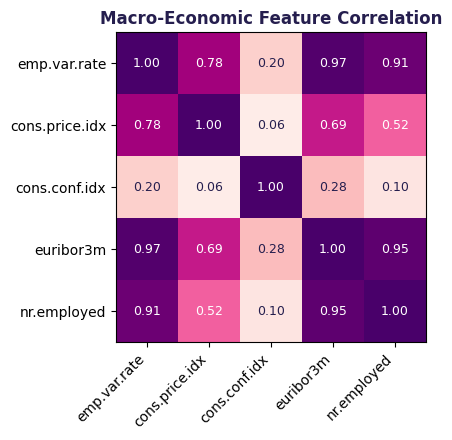

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap="RdPu", vmin=0, vmax=1)
ax.set_xticks(range(len(macro_cols)))
ax.set_xticklabels(macro_cols, rotation=45, ha="right")
ax.set_yticks(range(len(macro_cols)))
ax.set_yticklabels(macro_cols)
for i in range(len(macro_cols)):
    for j in range(len(macro_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if corr.iloc[i, j] > 0.5 else NAVY, fontsize=9)
ax.set_title("Macro-Economic Feature Correlation", color=NAVY, fontweight="bold")
plt.tight_layout()
plt.show()


`emp.var.rate`, `euribor3m`, and `nr.employed` move almost in lockstep (correlations of 0.91–0.97) — they're
largely telling us the same thing three times, each with its own noise layered on top. `cons.conf.idx` is the
outlier, far more independent of the rest.


### Task 2.2 — Fit PCA and check explained variance

Standardize first (PCA is scale-sensitive), then see how many components it actually takes to capture this
group's real signal.


In [10]:
scaler = StandardScaler()
macro_scaled = scaler.fit_transform(df_encoded[macro_cols])

pca = PCA()
pca.fit(macro_scaled)

explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

for i, (e, c) in enumerate(zip(explained, cumulative), start=1):
    print(f"PC{i}: {e:.1%} of variance  (cumulative {c:.1%})")


PC1: 69.4% of variance  (cumulative 69.4%)
PC2: 19.7% of variance  (cumulative 89.1%)
PC3: 10.2% of variance  (cumulative 99.3%)
PC4: 0.5% of variance  (cumulative 99.8%)
PC5: 0.2% of variance  (cumulative 100.0%)


Three components already capture ~99.3% of the variance across all five columns — the last two components
(under 1% combined) are essentially pure noise. That's our denoising budget: reconstruct using 3 components,
drop the rest.


### Task 2.3 — Reconstruct (denoise) the five columns

Project into the 3-component space, then project straight back. What comes back is the same five columns,
smoothed — the noise-only components never make it into the reconstruction.


In [11]:
pca_denoise = PCA(n_components=3)
macro_projected = pca_denoise.fit_transform(macro_scaled)
macro_reconstructed_scaled = pca_denoise.inverse_transform(macro_projected)
macro_reconstructed = scaler.inverse_transform(macro_reconstructed_scaled)

for i, col in enumerate(macro_cols):
    df_encoded[col + "_denoised"] = macro_reconstructed[:, i]

df_encoded[["euribor3m", "euribor3m_denoised", "cons.conf.idx", "cons.conf.idx_denoised"]].describe()


,euribor3m,euribor3m_denoised,cons.conf.idx,cons.conf.idx_denoised
count,41188.000000,41188.000000,41188.000000,41188.000000
mean,3.621291,3.621291,-40.502600,-40.502600
std,1.734447,1.728047,4.628198,4.627524
min,0.634000,0.525604,-50.800000,-50.459932
25%,1.344000,1.403655,-42.700000,-42.682601
50%,4.857000,4.758859,-41.800000,-41.945422
75%,4.961000,4.956026,-36.400000,-36.355739
max,5.045000,5.106738,-26.900000,-26.933476


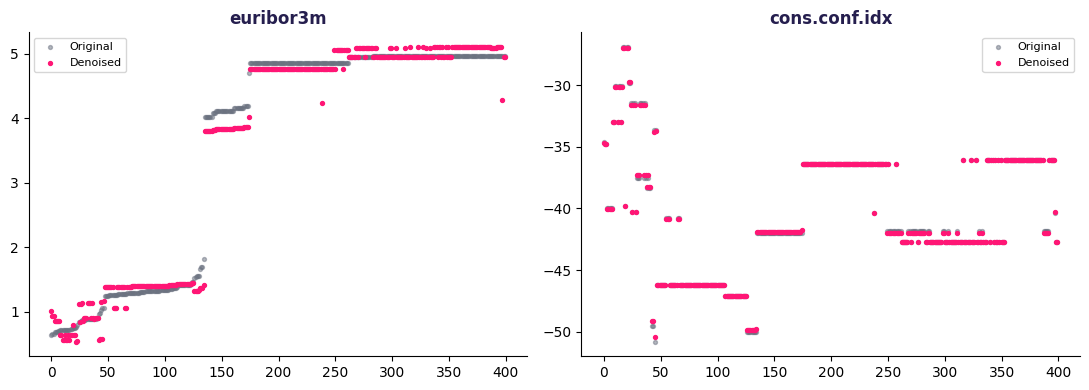

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sample = df_encoded.sample(400, random_state=1).sort_values("euribor3m")

for ax, col in zip(axes, ["euribor3m", "cons.conf.idx"]):
    ax.scatter(range(len(sample)), sample[col], s=8, color=GRAY, alpha=0.5, label="Original")
    ax.scatter(range(len(sample)), sample[col + "_denoised"], s=8, color=PINK, label="Denoised")
    ax.set_title(col, color=NAVY, fontweight="bold")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


**Talking point:** notice the denoised version tracks the same underlying shape as the original but with the
point-to-point jitter smoothed out. We haven't dropped any columns — a model using the `_denoised` versions still
sees five macro features, just five cleaner ones.


## Save the Engineered Feature Set

In [13]:
df_encoded.to_csv("bank_marketing_features.csv", sep=";", index=False)
print("Saved bank_marketing_features.csv —", df_encoded.shape)


Saved bank_marketing_features.csv — (41188, 50)


## Recap

- **Engineering** turns a raw-but-clean column into something that matches how the underlying relationship
  actually behaves — order-preserving for ordinal data, no-order for nominal data, wraparound-aware for cyclical
  data, ratio-aware where a single derived number beats two raw ones.
- **Denoising** is for the opposite problem: a whole *group* of features that are too correlated, each carrying
  a noisy version of one shared signal. PCA reconstruction keeps every column but strips the noise-only variance
  out of them.
- `bank_marketing_features.csv` is now the shared feature set for the rest of the course.

**Up next — Block 4:** Optimizing & Training Linear Models, starting from `bank_marketing_features.csv`.
